<a href="https://colab.research.google.com/github/Jingxian12/movie-recommender-system/blob/main/notebook/Movie_Recommender_System_(PART_B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<div align = center > TITLE : MOVIE RECOMMENDER SYSTEM**</div>


# **PART B : MODELING**

**Summary:**

I performed the development of an end-to-end Movie Recommendation System that integrates three distinct architectural approaches: **Collaborative Filtering, Content-Based Filtering, and Advanced NLP Semantic Search**.

- Using the `MovieLens-100k dataset`, the Collaborative Filtering engine implements **Item-Based, SVD, and Bayesian Personalized Ranking (BPR) models**, cross-evaluating their performance using Top-K metrics including `Precision@K`, `Recall@K`, `HitRate@K`, and `NDCG@K`.
- The Content-Based Filtering pipeline leverages an ETL process that unifies `TMDB API data and Kaggle datasets`, utilizing **TF-IDF vectorization** alongside strict algorithmic sanity checks.

- To maximize user query accuracy, the NLP-Based Filtering engine introduces a hybrid search experience, utilizing a **Sentence-BERT (SBERT)** `Bi-Encoder` for swift vector retrieval and a `Cross-Encoder` model to deeply re-rank candidate results for complex natural language queries.

For deployment, I hosted these three filtering engines on **`Streamlit Community Cloud`**, creating an interactive user interface that allows seamless exploration and real-time comparison of the different recommendation algorithms.





### **Import Necessary Libraries**

In [1]:
!pip install scikit-surprise
!pip install "numpy<2.0"
!pip install implicit scipy

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import pickle
import gzip

In [3]:
print(np.__version__)

1.26.4


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Phase 1 : Correlative Filtering**

### **A) Load Datasets**

#### **MovieLens and Ratings**

In [5]:
movieLens = pd.read_csv('/content/drive/MyDrive/dataset/movie/API/preprocess_dataset/movieLens.csv')
display(movieLens.head())
print()
print(movieLens.info())
print(movieLens.shape)

,movieId,title,genres,imdbId,tmdbId,media_type
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862,movie
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844,movie
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602,movie
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357,movie
4,5,Father of the Bride Part II (1995),Comedy,113041,11862,movie



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9739 entries, 0 to 9738
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   movieId     9739 non-null   int64 
 1   title       9739 non-null   object
 2   genres      9739 non-null   object
 3   imdbId      9739 non-null   int64 
 4   tmdbId      9739 non-null   int64 
 5   media_type  9739 non-null   object
dtypes: int64(3), object(3)
memory usage: 456.6+ KB
None
(9739, 6)


In [6]:
movieLens.isna().sum()

,0
movieId,0
title,0
genres,0
imdbId,0
tmdbId,0
media_type,0


In [7]:
ratings = pd.read_csv('/content/drive/MyDrive/dataset/movie/API/preprocess_dataset/ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


#### **Merge Dataset**

In [8]:
merged_df = pd.merge(ratings, movieLens, on='movieId')
display(merged_df.head())
print()
print(merged_df.info())
print(merged_df.shape)

,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId,media_type
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862,movie
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,113228,15602,movie
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,113277,949,movie
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807,movie
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629,movie



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   userId      100836 non-null  int64  
 1   movieId     100836 non-null  int64  
 2   rating      100836 non-null  float64
 3   timestamp   100836 non-null  int64  
 4   title       100836 non-null  object 
 5   genres      100836 non-null  object 
 6   imdbId      100836 non-null  int64  
 7   tmdbId      100836 non-null  int64  
 8   media_type  100836 non-null  object 
dtypes: float64(1), int64(5), object(3)
memory usage: 6.9+ MB
None
(100836, 9)


In [9]:
merged_df.isna().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0
title,0
genres,0
imdbId,0
tmdbId,0
media_type,0


### **B) EDA**

#### 1. Rating Distribution

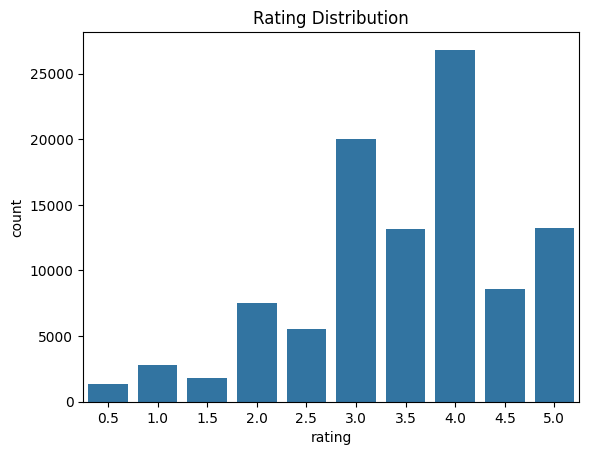

In [10]:
sns.countplot(x="rating", data=merged_df)
plt.title("Rating Distribution")
plt.show()

Graph
- The most frequent rating is 4.0, which has the highest count.
- Ratings of 3.0 and 5.0 also have high frequencies, showing that most users tend to give positive feedback.
- Lower ratings such as 0.5, 1.0, and 1.5 are very rare.

#### 2. Most rated movies

In [11]:
top_movies = merged_df.groupby("title").size().sort_values(ascending=False).head(10)
top_movies

,0
title,
Forrest Gump (1994),329
"Shawshank Redemption, The (1994)",317
Pulp Fiction (1994),307
"Silence of the Lambs, The (1991)",279
"Matrix, The (1999)",278
Star Wars: Episode IV - A New Hope (1977),251
Jurassic Park (1993),238
Braveheart (1995),237
Terminator 2: Judgment Day (1991),224


From Table, the values is represent how many user rate the movie.
- Forrest Gump (1994) → 329 ratings
- Shawshank Redemption → 317 ratings
-  Pulp Fiction → 307 ratings

P.S. But does not mean that these are the highest rated movies, It just mean many people rated this movie

#### 3. Average rating per movie




In [12]:
movie_stats = merged_df.groupby("title").agg({
    "rating": ["mean", "count"]
})

movie_stats.columns = ["mean_rating", "num_ratings"]
movie_stats = movie_stats.sort_values("num_ratings", ascending=False)

movie_stats.head()

,mean_rating,num_ratings
title,,
Forrest Gump (1994),4.164134,329
"Shawshank Redemption, The (1994)",4.429022,317
Pulp Fiction (1994),4.197068,307
"Silence of the Lambs, The (1991)",4.161290,279
"Matrix, The (1999)",4.192446,278


The most-rated movies all have average ratings above 4.0, meaning:
- users generally liked these movies
- popularity and satisfaction are both high

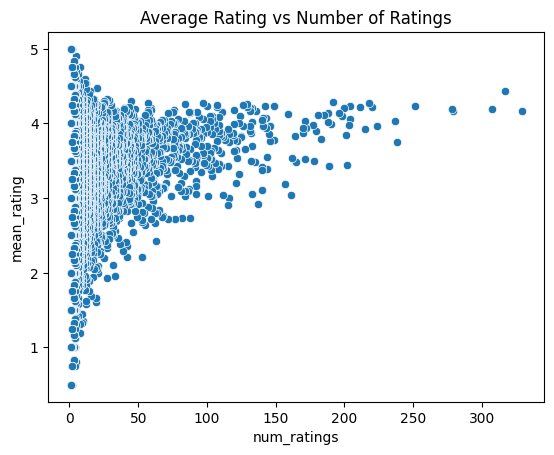

In [13]:
sns.scatterplot(
    x="num_ratings",
    y="mean_rating",
    data=movie_stats
)
plt.title("Average Rating vs Number of Ratings")
plt.show()

The scatter plot shows that movies with a higher number of ratings generally maintain average ratings above 3.5. While movies with fewer ratings exhibit large variability in average scores, highly rated movies with many ratings appear more stable and reliable. This suggests that popular movies in the dataset are generally well-received by users.

#### 4. Distribution of Ratings by Media Type

--- Original Media Type Counts ---
media_type
movie    100649
tv          187
Name: count, dtype: int64


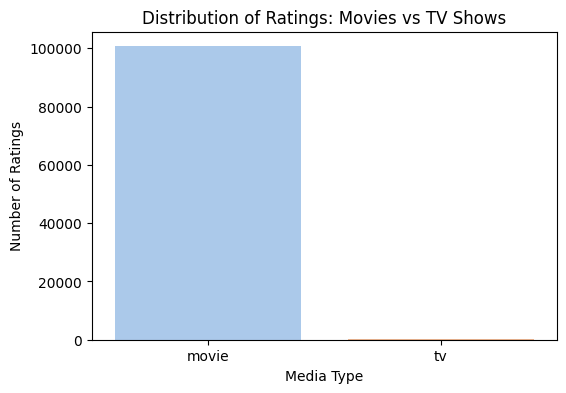

In [14]:
print("--- Original Media Type Counts ---")
print(merged_df["media_type"].value_counts(dropna=False))

plt.figure(figsize=(6, 4))
sns.countplot(data=merged_df, x="media_type", hue="media_type", palette="pastel", legend=False)
plt.title("Distribution of Ratings: Movies vs TV Shows")
plt.xlabel("Media Type")
plt.ylabel("Number of Ratings")
plt.show()

In [15]:
merged_df = merged_df[merged_df["media_type"] != "tv"]

TV shows were removed because they account for less than 0.2% of the dataset and present TMDB ID collision risks, as TMDB manages movies and TV shows via separate endpoint paths which can cause duplicate IDs in a unified movie recommendation matrix

In [16]:
duplicates = merged_df[merged_df.duplicated(subset=['userId', 'movieId'], keep=False)]
print("This row is causing the mismatch:")
print(duplicates[['userId', 'movieId', 'rating']])

This row is causing the mismatch:
       userId  movieId  rating
17449     111   144606     4.0
17819     111   144606     4.0


In [17]:
merged_df = merged_df.drop_duplicates(subset=['userId', 'movieId'])
merged_df.shape

(100648, 9)

#### 5. Sparsity Analysis



Sparsity analysis refers to analyzing:
- How many missing values exist in the user–movie matrix
- In recommendation systems, sparsity occurs because most users interact with only a **small number of items**, leaving many empty cells in the matrix.

In [18]:
user_movie_matrix_eda = merged_df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

In [19]:
user_movie_matrix_eda.shape

(610, 9649)

In [20]:
num_ratings = user_movie_matrix_eda.count().sum()

total_possible = (
    user_movie_matrix_eda.shape[0] *
    user_movie_matrix_eda.shape[1]
)

sparsity = 1 - (num_ratings / total_possible)
print("Number of Ratings :",num_ratings)
print("Total possible ratings:",total_possible)
print()
print(f"Sparsity: {sparsity:.2%}")

Number of Ratings : 100648
Total possible ratings: 5885890

Sparsity: 98.29%


A sparsity value of 98.29% indicates that the user–movie matrix is highly sparse, meaning that most users rated only a very small number of movies.

- 98.29% of the user–movie matrix is **empty** (missing ratings).

The high sparsity may reduce similarity accuracy for less-rated movies.
- Therefore, advanced techniques such as `SVD` or `matrix factorization` may provide better performance in handling sparse recommendation data.

We will try **memory-based(item-based filtering)** and **model-based(matrix factorization)**, and compare the evaluation metrics.

#### - Remove unnecessary columns

In [21]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100648 entries, 0 to 100835
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   userId      100648 non-null  int64  
 1   movieId     100648 non-null  int64  
 2   rating      100648 non-null  float64
 3   timestamp   100648 non-null  int64  
 4   title       100648 non-null  object 
 5   genres      100648 non-null  object 
 6   imdbId      100648 non-null  int64  
 7   tmdbId      100648 non-null  int64  
 8   media_type  100648 non-null  object 
dtypes: float64(1), int64(5), object(3)
memory usage: 7.7+ MB


In [22]:
merged_df = merged_df.drop(columns=["timestamp","title","genres","media_type"])
merged_df.head()

,userId,movieId,rating,imdbId,tmdbId
0,1,1,4.0,114709,862
1,1,3,4.0,113228,15602
2,1,6,4.0,113277,949
3,1,47,5.0,114369,807
4,1,50,5.0,114814,629


### **C) Set a threshold for movie and ratings**

In [23]:
threshold_df = merged_df.copy()

In [24]:
threshold_df.shape

(100648, 5)

In [25]:
# 1. First, apply the Global Filter to keep ONLY liked movies (ratings >= 3.5)
threshold_df = threshold_df[threshold_df["rating"] >= 3.5]

# Remove inactive users and unpopular movies
min_movie_ratings = 10
min_user_ratings = 25

# Filter movies
movie_counts = threshold_df['movieId'].value_counts()
valid_movies = movie_counts[movie_counts >= min_movie_ratings].index

# Filter users
user_counts = threshold_df['userId'].value_counts()
valid_users = user_counts[user_counts >= min_user_ratings].index

# Clean dataset
ratings_clean = threshold_df[
    (threshold_df['movieId'].isin(valid_movies)) &
    (threshold_df['userId'].isin(valid_users))
]
print("Cleaned Dataset Shape:", ratings_clean.shape)

# Print the number of unique users and movies
num_users = ratings_clean['userId'].nunique()
num_movies = ratings_clean['movieId'].nunique()

print(f"Number of unique users: {num_users}")
print(f"Number of unique movies: {num_movies}")

Cleaned Dataset Shape: (44579, 5)
Number of unique users: 438
Number of unique movies: 1435


In [26]:
display(ratings_clean.head())

,userId,movieId,rating,imdbId,tmdbId
0,1,1,4.0,114709,862
1,1,3,4.0,113228,15602
2,1,6,4.0,113277,949
3,1,47,5.0,114369,807
4,1,50,5.0,114814,629


The cleaned dataset contains **44,579 reviews**, where every included user has rated **at least 25 movies with 3.5 or above**,  and every included **movie** has received **at least 10 ratings.**

In [27]:
# ratings_clean.to_csv("ratings_clean.csv", index=False)

# # Save files to local computer
# from google.colab import files
# files.download("ratings_clean.csv")

### **D) Per-user Leave-P-Out Split**
- The dataset was split using a stratified per-user `Leave-5-Out method`. For each user profile, exactly 5 randomly selected movie ratings were withheld for the test set, while all remaining interactions were allocated to the training set.
- This establishes a uniform baseline across all profiles, allowing for mathematically perfect evaluation of Top-K ranking metrics like **Precision@5, Recall@5, and NDCG@5.**

- Splitting data at the individual user level ensures every user is represented in both sets, preventing the user `cold-start problem` during evaluation.

#### **Cold Start**
- The cold start problem happens when new users or items lack enough data for accurate recommendations. To prevent this, a $k$-core filter was applied to guarantee that every user has at least 25 ratings (leaving 20+ for training) and every movie has at least 10 ratings, ensuring robust model learning.

In [28]:
def user_leave_p_out_split(df, p=5):
    train_list = []
    test_list = []

    for user_id, user_data in df.groupby("userId"):
        # Shuffle the user's data randomly before splitting
        user_data = user_data.sample(frac=1, random_state=42)

        # The last p items go to test; everything before that goes to train
        # (e.g., if p=5, .iloc[:-5] grabs all rows except the last 5)
        train_list.append(user_data.iloc[:-p])
        test_list.append(user_data.iloc[-p:])

    train_df = pd.concat(train_list).reset_index(drop=True)
    test_df = pd.concat(test_list).reset_index(drop=True)

    return train_df, test_df

In [29]:
train_df, test_df = user_leave_p_out_split(ratings_clean, p=5)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (42389, 5)
Test shape: (2190, 5)


In [30]:
train_users = set(train_df['userId'])
test_users = set(test_df['userId'])

train_movies = set(train_df['tmdbId'])
test_movies = set(test_df['tmdbId'])

# Check for "Orphan" Users/Movies in the Test Set
unseen_users = test_users - train_users
unseen_movies = test_movies - train_movies

print(f"🚨 Unseen users in test set: {len(unseen_users)}")
print(f"🚨 Unseen movies in test set: {len(unseen_movies)}")

🚨 Unseen users in test set: 0
🚨 Unseen movies in test set: 0


In [31]:
# Ground truth = movies the user actually liked in the TEST set
def get_user_ground_truth(test_df):
    return test_df.groupby("userId")["tmdbId"].apply(list).to_dict()

ground_truth = get_user_ground_truth(test_df)

"The ground truth was constructed directly from the Leave-5-Out test set. Since the dataset was pre-filtered for ratings $\ge 3.5$, these hidden items represent guaranteed positive implicit feedback, serving as a clean baseline for evaluating Top-K recommendation ranking performance.

### **E) Modeling**

### **Evaluation Metrics**

**Precision @ K**
- Measures the proportion of recommended items in the top K that are actually relevant to the user.

**Recall @ K**
- Measures the proportion of all relevant items that are successfully retrieved in the top K recommendations.

**Hit Rate @ K**
- Measures whether at least one relevant item appears in the top K recommendations for a user (1 if yes, 0 if no).

**NDCG @ K (Normalized Discounted Cumulative Gain)**
- Measures the quality of the ranking by giving higher importance to relevant items that appear earlier in the top K list.

In [32]:
#recommended:model output (ranked list)
# relevant: ground truth (liked movies)

# Precision @ K
def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k] #start from 0
    hits = len(set(recommended_k) & set(relevant))

    return hits / k

# Recall @ K
def recall_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    if len(relevant) == 0:
        return 0

    return hits / len(relevant)

# HitRate @ K
def hit_rate_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))

    return 1 if hits > 0 else 0

# NDCG @ K
def dcg_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    dcg = 0
    for i, movie in enumerate(recommended_k):
        if movie in relevant:
            dcg += 1 / np.log2(i + 2)

    return dcg


def ndcg_at_k(recommended, relevant, k):
    actual_dcg = dcg_at_k(recommended, relevant, k)

    # Correcting the Ideal DCG (IDCG) alignment:
    # If a user only likes 3 movies in total, the perfect recommendation list
    # would hit those 3 movies first, followed by 7 misses.
    # The ideal hit sequence would look like: [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
    num_hits_possible = min(len(relevant), k)

    if num_hits_possible == 0:
        return 0

    # Calculate the DCG score for this ideal sequence
    ideal_dcg = sum(1 / np.log2(i + 2) for i in range(num_hits_possible))

    return actual_dcg / ideal_dcg

In [33]:
# Main Evaluation Engine for Top N Recommender Systems (all users)
def evaluate_topn(recommendations_dict, ground_truth, k=5):
    precision_list = []
    recall_list = []
    hitrate_list = []
    ndcg_list = []

    for user_id, recommended_movies in recommendations_dict.items():
        if user_id not in ground_truth:
            continue

        relevant_movies = ground_truth[user_id]
        precision_list.append(
            precision_at_k(recommended_movies,relevant_movies,k)
        )

        recall_list.append(
            recall_at_k(recommended_movies,relevant_movies,k)
        )

        hitrate_list.append(
            hit_rate_at_k(recommended_movies,relevant_movies,k)
        )

        ndcg_list.append(ndcg_at_k(recommended_movies,relevant_movies,k)
        )

    return {
    f"Precision@{k}": float(np.mean(precision_list)),
    f"Recall@{k}": float(np.mean(recall_list)),
    f"HitRate@{k}": float(np.mean(hitrate_list)),
    f"NDCG@{k}": float(np.mean(ndcg_list))
    }

### **Method 1 : Item Based Filtering**

**Item-Based Collaborative Filtering** is a recommendation technique that suggests movies based on **how similar they are to a given movie** by using user rating patterns.

- Idea : Let say `Movie A` and `Movie B` have a high similarity based on community behavior, an item-based system recommends `Movie B` to any user who previously liked `Movie A`.

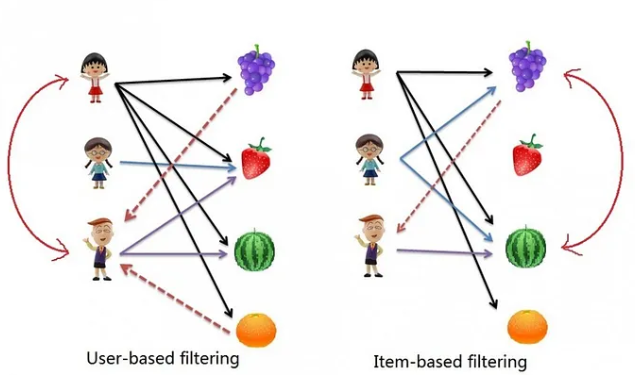

#### **User-Item Matrix**

In [34]:
train_user_item_matrix = train_df.pivot_table(
    index='userId',
    columns='tmdbId',
    values='rating'
).fillna(0)

In [35]:
train_user_item_matrix.T

userId,1,4,6,7,10,11,12,15,16,17,...,600,601,602,603,604,605,606,607,608,610
tmdbId,,,,,,,,,,,,,,,,,,,,,
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0
11,5.0,5.0,0.0,5.0,0.0,0.0,0.0,5.0,0.0,5.0,...,4.0,0.0,5.0,4.0,0.0,5.0,4.5,0.0,3.5,5.0
12,0.0,0.0,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0,...,4.0,5.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,4.0
13,4.0,0.0,5.0,5.0,3.5,5.0,0.0,5.0,3.5,5.0,...,4.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0
14,5.0,5.0,0.0,4.0,0.0,0.0,0.0,4.0,3.5,4.0,...,4.5,0.0,0.0,5.0,0.0,0.0,4.5,0.0,5.0,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318846,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
329865,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
330459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0


#### **Item Similarity**

In [36]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(train_user_item_matrix.T) # sklearn calculate rows by rows

item_similarity_df = pd.DataFrame(
    item_similarity,
    index= train_user_item_matrix.columns,
    columns= train_user_item_matrix.columns
)

In [37]:
item_similarity_df.head()

tmdbId,5,11,12,13,14,15,16,18,19,22,...,290250,293660,299536,314365,315635,318846,329865,330459,335984,503475
tmdbId,,,,,,,,,,,,,,,,,,,,,
5,1.000000,0.156700,0.148231,0.156819,0.108743,0.087790,0.189061,0.144586,0.341875,0.128469,...,0.106901,0.057585,0.115257,0.000000,0.093254,0.097771,0.063073,0.074733,0.078447,0.153422
11,0.156700,1.000000,0.385743,0.511639,0.504807,0.348596,0.158911,0.464269,0.206688,0.419565,...,0.165263,0.258881,0.153743,0.195969,0.220753,0.162064,0.201236,0.293646,0.174228,0.180794
12,0.148231,0.385743,1.000000,0.494767,0.377066,0.243877,0.137043,0.377455,0.196441,0.584937,...,0.182138,0.262535,0.137194,0.240279,0.200603,0.199594,0.151811,0.204949,0.168218,0.168510
13,0.156819,0.511639,0.494767,1.000000,0.488393,0.271891,0.100343,0.398797,0.183557,0.437863,...,0.169932,0.276486,0.143236,0.203150,0.188730,0.184062,0.179237,0.196565,0.186465,0.144317
14,0.108743,0.504807,0.377066,0.488393,1.000000,0.405916,0.240973,0.390736,0.221989,0.378281,...,0.146593,0.183189,0.060871,0.191309,0.127015,0.186977,0.168260,0.162262,0.164754,0.197121


**Quick Overview**
- Matrix shows how close movies are to each other.

**Score MeaningsScore**
- 1: Perfect match (identical movies)
- 0: Zero match (completely different movies).

**Example:**  High/Moderate Match (0.416799): Movie 1 & Movie 2. Similar taste profiles.


In [38]:
def recommend_item_based(user_id, top_n=5):
    # Make sure user inside train data
    if user_id not in train_user_item_matrix.index:
          return []
    # 1. Get the user's rating vector for all movies
    user_ratings = train_user_item_matrix.loc[user_id].copy() # loc : access rows, columns by using labels name

    # 2. Identify movies already rated by the user
    watched_in_train = user_ratings[user_ratings > 0].index

    # 3. Keep only rated movies for recommendation scoring
    user_ratings[user_ratings <= 0] = 0

    # 4. Compute recommendation scores using matrix multiplication
    # User rating vector (1 x num_movies) multiplied by item similarity matrix (num_movies x num_movies)
    scores_series = item_similarity_df.dot(user_ratings)

    # 5. Remove movies already watched by the user
    scores_series = scores_series.drop(watched_in_train,errors='ignore') # skips missing labels safely.

    # 6. Remove non-positive recommendation scores
    scores_series = scores_series[scores_series > 0]

    # 7. Return Top-K highest scored movies
    if scores_series.empty:
        return []

    return scores_series.sort_values(ascending=False).head(top_n).index.tolist()


In [39]:
item_recommendations = {}

for user_id in ground_truth.keys():
    item_recommendations[user_id] = recommend_item_based(user_id,top_n=5)


In [40]:
item_results = evaluate_topn(item_recommendations,ground_truth,k=5)

item_evaluation_df = pd.DataFrame([item_results])
item_evaluation_df= item_evaluation_df.astype(float)

print(item_evaluation_df)

   Precision@5  Recall@5  HitRate@5   NDCG@5
0     0.126941  0.126941   0.461187  0.13849


#### **Save 100% matrix for UI**

In [41]:
user_item_matrix = ratings_clean.pivot_table(
    index='userId',
    columns='tmdbId',
    values='rating'
).fillna(0)

In [42]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(user_item_matrix.T) # sklearn calculate rows by rows

item_similarity_df = pd.DataFrame(
    item_similarity,
    index= user_item_matrix.columns,
    columns= user_item_matrix.columns
)

In [43]:
movie_ids = item_similarity_df.index.tolist()

top_k = 5
item_topk = {}

# Use .values to extract a pure NumPy array for a massive speed boost
similarity_matrix = item_similarity_df.values

for i, movie_id in enumerate(movie_ids):
    # 1. Extract the similarity scores of the current movie against all other movies
    raw_scores = similarity_matrix[i]

    # 2. Core Fix: Pair the scores with the ACTUAL movie IDs instead of sequential index positions (0, 1, 2...)
    id_score_pairs = list(zip(movie_ids, raw_scores))

    # 3. Sort the pairs in descending order based on the similarity score
    id_score_pairs_sorted = sorted(id_score_pairs, key=lambda x: x[1], reverse=True)

    # 4. Slice the Top-K matches (Skip index 0 because a movie's similarity with itself is always 1.0)
    item_topk[int(movie_id)] = id_score_pairs_sorted[1:top_k+1]

In [ ]:
# with gzip.open("item_topk.pkl.gz", "wb") as f:
#     pickle.dump(item_topk, f)

# # Downlaod to local computer
# from google.colab import files
# files.download("item_topk.pkl.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Method 2 : SVD**

**SVD (Singular Value Decomposition)** is a recommendation technique that **predicts missing ratings by discovering hidden patterns** (latent factors) between users and movies.

In [44]:
from surprise import Dataset, Reader, SVD

reader = Reader(rating_scale=(0.5, 5))

train_surprise = Dataset.load_from_df(
    train_df[['userId', 'tmdbId', 'rating']],
    reader
)

trainset = train_surprise.build_full_trainset()

In [45]:
svd_model = SVD()
svd_model.fit(trainset)

In [46]:
# 3. Cleaned Recommendation Function
def recommend_svd(user_id, model, train_user_item, all_movie_ids, top_n=5):
    """Generates Top-N recommendations for a specific user using a trained SVD model."""

    if user_id in train_user_item.index:
        user_vector = train_user_item.loc[user_id]
        watched_movies = set(user_vector[user_vector > 0].index)
    else:
        watched_movies = set()

    unwatched_movies = [movie_id for movie_id in all_movie_ids if movie_id not in watched_movies]
    # Predicting Ratings with the SVD Model
    predictions = []
    for movie_id in unwatched_movies:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    # Sorting and Extracting the Top N
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n_recommendations = [movie_id for movie_id, score in predictions[:top_n]]

    return top_n_recommendations

In [47]:
# Extract all unique movie IDs from your training set universe
all_movie_ids = train_df['tmdbId'].unique().tolist()

svd_recommendations = {}

# Generate predictions for every user present in your evaluation ground truth
for user_id in ground_truth.keys():
    svd_recommendations[user_id] = recommend_svd(
        user_id=user_id,
        model=svd_model, # Pass your fitted surprise SVD instance
        train_user_item=train_user_item_matrix,  # Your training pivot table
        all_movie_ids=all_movie_ids,
        top_n=10
    )

# Run it through your existing evaluation engine!
svd_results = evaluate_topn(
    svd_recommendations,
    ground_truth,
    k=5
)

In [48]:
svd_evaluation_df = pd.DataFrame([svd_results])
svd_evaluation_df= svd_evaluation_df.astype(float)

print(svd_evaluation_df)

   Precision@5  Recall@5  HitRate@5    NDCG@5
0     0.011872  0.011872   0.059361  0.012363


### **Method 3 : BPR**

**Bayesian Personalized Ranking (BPR)** is a pairwise optimization framework that trains recommendation models to rank items a user has interacted with higher than items they haven't.
- Compare items in pairs, and put the preferred one first.


In [49]:
import implicit
from scipy.sparse import csr_matrix

# =====================================================================
# 1. PREPARE THE DATA (Implicit Feedback)
# =====================================================================
# BPR treats ratings >= 3.0 as positive interactions (1), and ignores the rest.
positive_train = train_df[train_df['rating'] >= 3.5].copy()

# Map userIds and tmdbIds to clean, contiguous integer indices for mapping
positive_train['user_encoded'] = positive_train['userId'].astype('category').cat.codes
positive_train['item_encoded'] = positive_train['tmdbId'].astype('category').cat.codes

# Create lookup dictionaries to map back and forth later
user_lookup = dict(zip(positive_train['userId'], positive_train['user_encoded']))
item_lookup = dict(zip(positive_train['item_encoded'], positive_train['tmdbId']))

num_users = positive_train['user_encoded'].nunique()
num_items = positive_train['item_encoded'].nunique()

# Create a User-Item Sparse Matrix (CSR Matrix)
# Implicit feedback binary array: data is just an array of 1s representing "watched"
user_item_matrix = csr_matrix(
    (np.ones(len(positive_train)), (positive_train['user_encoded'], positive_train['item_encoded'])),
    shape=(num_users, num_items)
)

# =====================================================================
# 2. INITIALIZE AND TRAIN THE BPR MODEL
# =====================================================================
# factors: embedding dimensions (latent factors)
# learning_rate: step size for gradient descent
# regularization: L2 penalty to prevent overfitting
bpr_model = implicit.bpr.BayesianPersonalizedRanking(
    factors=64,
    learning_rate=0.05,
    regularization=0.01,
    iterations=50,
    random_state=42
)

# Train the model (expects an Item-User or User-Item sparse matrix depending on settings)
bpr_model.fit(user_item_matrix)

  0%|          | 0/50 [00:00<?, ?it/s]

In [50]:
# =====================================================================
# 3. DEFINE THE BPR RECOMMENDATION FUNCTION
# =====================================================================
def recommend_bpr(user_id, model, user_item_matrix, user_lookup, item_lookup, top_n=5):
    """
    Generates Top-N recommendations for a specific user using the trained BPR model.
    """
    # Handle Cold Start: If user wasn't in the positive training data
    if user_id not in user_lookup:
        return []

    # Get the internal index mapping for this user
    user_encoded_id = user_lookup[user_id]

    # model.recommend expects the user index and their row vector from the matrix
    # filter_already_liked_items=True completely blocks movies they already watched in train
    ids, scores = model.recommend(
        userid=user_encoded_id,
        user_items=user_item_matrix[user_encoded_id],
        N=top_n,
        filter_already_liked_items=True
    )

    # Map internal item indices back to your original tmdbIds
    top_n_recommendations = [item_lookup[item_idx] for item_idx in ids]

    return top_n_recommendations

In [51]:
# =====================================================================
# 4. BATCH GENERATION & EVALUATION LOOP
# =====================================================================
bpr_recommendations = {}

for user_id in ground_truth.keys():
    bpr_recommendations[user_id] = recommend_bpr(
        user_id=user_id,
        model=bpr_model,
        user_item_matrix=user_item_matrix,
        user_lookup=user_lookup,
        item_lookup=item_lookup,
        top_n=5
    )

# Feed it right into your existing grading script!
bpr_results = evaluate_topn(
    bpr_recommendations,
    ground_truth,
    k=5
)

In [52]:
bpr_evaluation_df = pd.DataFrame([bpr_results])
bpr_evaluation_df= bpr_evaluation_df.astype(float)

print(bpr_evaluation_df)

   Precision@5  Recall@5  HitRate@5    NDCG@5
0     0.071689  0.071689   0.319635  0.078359


### **Comparison**

In [53]:
comparison_df = pd.concat(
    [item_evaluation_df, svd_evaluation_df,bpr_evaluation_df],
    axis=0
)
comparison_df.index = ["Item-Based CF", "SVD", 'BPR']

comparison_df

,Precision@5,Recall@5,HitRate@5,NDCG@5
Item-Based CF,0.126941,0.126941,0.461187,0.138490
SVD,0.011872,0.011872,0.059361,0.012363
BPR,0.071689,0.071689,0.319635,0.078359


Based On these three method, I chose **Item-Based Collaborative Filtering** for deployment because it consistently outperformed both SVD and BPR across all key evaluation metrics at `K=5`. Specifically, it achieved the highest Precision, Recall, Hit Rate, and NDCG, demonstrating superior accuracy and ranking quality for the movie recommendations.

## **Phase 2 : Content Based Filtering**

### **A) Load Dataset**

In [54]:
tmdb = pd.read_csv('/content/drive/MyDrive/dataset/movie/API/preprocess_dataset/final_tmdb_api.csv')

In [55]:
display(tmdb.head(1))
print(tmdb.shape)

,cache_key,status,poster_status,media_type,source,tmdbId,title,genres,keywords,original_language,...,production_companies,release_date,runtime,popularity,vote_average,vote_count,cast,director,poster_path,poster_url
0,movie_19995,success,success,movie,kaggle,19995,Avatar,"['Action', 'Adventure', 'Fantasy', 'Science Fi...","['culture clash', 'future', 'space war', 'spac...",en,...,"['Ingenious Film Partners', 'Twentieth Century...",2009-12-10,162.0,150.437577,7.2,11800.0,"[{'character': 'Jake Sully', 'name': 'Sam Wort...",['James Cameron'],/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,https://image.tmdb.org/t/p/w500/gKY6q7SjCkAU6F...


(10936, 21)


In [56]:
tmdb.iloc[0]

,0
cache_key,movie_19995
status,success
poster_status,success
media_type,movie
source,kaggle
tmdbId,19995
title,Avatar
genres,"['Action', 'Adventure', 'Fantasy', 'Science Fi..."
keywords,"['culture clash', 'future', 'space war', 'spac..."
original_language,en


### **B) Data Checking**

After extracting movie metadata via the TMDB API **(Part A)**, some requests failed, so the dataset is now being loaded to inspect the status of each record

In [57]:
tmdb['status'].value_counts()

,count
status,
success,10905
failed,31


In [58]:
fail_movielens = tmdb[tmdb['status'] == 'failed']
fail_movielens

,cache_key,status,poster_status,media_type,source,tmdbId,title,genres,keywords,original_language,...,production_companies,release_date,runtime,popularity,vote_average,vote_count,cast,director,poster_path,poster_url
1075,movie_82525,failed,failed,movie,kaggle,82525,Savages,"['Crime', 'Drama', 'Thriller']","['widow', 'american abroad', 'eye gouging', 'd...",en,...,"['Ixtlan', 'Relativity Media', 'Onda Entertain...",2012-07-06,131.0,31.856589,6.2,766.0,"[{'character': 'Ophelia ""O"" Sage', 'name': 'Bl...",['Oliver Stone'],NaN,NaN
1151,movie_10398,failed,failed,movie,kaggle,10398,Double Jeopardy,"['Crime', 'Drama', 'Mystery', 'Thriller']","['prison', 'sailboat', 'sailing trip', 'new or...",en,...,['Paramount Pictures'],1999-09-24,105.0,19.439386,6.2,278.0,"[{'character': 'Travis Lehman', 'name': 'Tommy...",['Bruce Beresford'],NaN,NaN
1464,movie_310706,failed,failed,movie,kaggle,310706,Black Water Transit,"['Drama', 'Crime']",[],en,...,['Capitol Films'],2009-05-13,100.0,0.126738,0.0,0.0,"[{'character': 'Jack', 'name': 'Laurence Fishb...",['Tony Kaye'],NaN,NaN
2630,movie_112430,failed,failed,movie,kaggle,112430,The Company,['Drama'],['miniseries'],en,...,[],2007-08-05,276.0,1.485324,7.0,12.0,"[{'character': 'Jack McAuliffe', 'name': ""Chri...",['Mikael Salomon'],NaN,NaN
3206,movie_333355,failed,failed,movie,kaggle,333355,Star Wars: Clone Wars: Volume 1,"['Action', 'Adventure', 'Animation', 'Fantasy'...","['war', 'space opera', 'clone troopers']",en,...,"['Lucasfilm', 'Cartoon Network Studios']",2005-03-21,69.0,1.881466,8.0,27.0,"[{'character': 'Yoda', 'name': 'Tom Kane'}, {'...",['Genndy Tartakovsky'],NaN,NaN
3283,movie_153397,failed,failed,movie,kaggle,153397,Restless,"['TV Movie', 'Romance', 'Drama']","['spy', 'war', 'british secret service']",en,...,"['British Broadcasting Corporation (BBC)', 'Su...",2012-12-07,180.0,0.812776,4.9,8.0,"[{'character': 'Eva Delectorskaya', 'name': 'H...",['Edward Hall'],NaN,NaN
3290,movie_36597,failed,failed,movie,kaggle,36597,Wuthering Heights,['Drama'],['woman director'],en,...,[],2009-01-18,142.0,4.409263,6.9,37.0,"[{'character': 'Heathcliff', 'name': 'Tom Hard...",['Coky Giedroyc'],NaN,NaN
3508,movie_183894,failed,failed,movie,kaggle,183894,Emma,"['Romance', 'Comedy', 'Drama']",[],en,...,[],2009-10-11,240.0,2.135689,7.6,38.0,"[{'character': 'Emma', 'name': 'Romola Garai'}...","[""Jim O'Hanlon""]",NaN,NaN
3613,movie_11042,failed,failed,movie,kaggle,11042,The Barbarian Invasions,"['Comedy', 'Crime', 'Drama']","['father son relationship', 'socialism', 'yupp...",fr,...,"['Pyramide Productions', 'Cinémaginaire Inc.',...",2003-05-21,99.0,3.030910,6.7,77.0,"[{'character': 'Rémy', 'name': 'Rémy Girard'},...",['Denys Arcand'],NaN,NaN
3847,movie_395766,failed,failed,movie,kaggle,395766,The Secret,['Drama'],['miniseries'],en,...,[],2016-04-29,200.0,0.042346,0.0,0.0,"[{'character': '', 'name': 'James Nesbitt'}, {...",['Nick Murphy '],NaN,NaN


- Rows with `status = failed` and `source = movielens` indicate that the corresponding TMDB metadata is no longer available for those MovieLens entries, so these records are removed,
- Rows with `status = failed` and `source = kaggle` are retained as they only lack poster data but still contain usable movie information.

In [59]:
tmdb = tmdb[~((tmdb['status'] == 'failed') & (tmdb['source'] == 'movielens'))]

In [60]:
tmdb.shape

(10924, 21)

#### **Drop cache columns**

In [61]:
tmdb = tmdb.drop(columns=['status','poster_status', 'source'])

In [62]:
tmdb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10924 entries, 0 to 10935
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cache_key             10924 non-null  object 
 1   media_type            10924 non-null  object 
 2   tmdbId                10924 non-null  int64  
 3   title                 10924 non-null  object 
 4   genres                10924 non-null  object 
 5   keywords              10924 non-null  object 
 6   original_language     10924 non-null  object 
 7   overview              10923 non-null  object 
 8   production_companies  10924 non-null  object 
 9   release_date          10924 non-null  object 
 10  runtime               10909 non-null  float64
 11  popularity            10924 non-null  float64
 12  vote_average          10924 non-null  float64
 13  vote_count            10924 non-null  float64
 14  cast                  10924 non-null  object 
 15  director              10

### **C) Data Preprocessing**

In [63]:
tmdb_df = tmdb.copy()

In [64]:
tmdb_df.head(1)

,cache_key,media_type,tmdbId,title,genres,keywords,original_language,overview,production_companies,release_date,runtime,popularity,vote_average,vote_count,cast,director,poster_path,poster_url
0,movie_19995,movie,19995,Avatar,"['Action', 'Adventure', 'Fantasy', 'Science Fi...","['culture clash', 'future', 'space war', 'spac...",en,"In the 22nd century, a paraplegic Marine is di...","['Ingenious Film Partners', 'Twentieth Century...",2009-12-10,162.0,150.437577,7.2,11800.0,"[{'character': 'Jake Sully', 'name': 'Sam Wort...",['James Cameron'],/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,https://image.tmdb.org/t/p/w500/gKY6q7SjCkAU6F...


#### **- Convert nested list/dict structures into clean comma-separated strings**

In [65]:
cols = ['genres', 'keywords', 'production_companies', 'director', 'cast']

def clean_feature(x, is_cast=False):
    if pd.isna(x):
        return np.nan

    # convert string → list if needed
    if isinstance(x, str): # Is x an instance of a string?
        try:
            x = ast.literal_eval(x)
        except:
            return np.nan

    # convert empty list → NaN
    if isinstance(x, list) and len(x) == 0:
        return np.nan

    # cast column (dict handling)
    if is_cast:
        if isinstance(x, list):
            names = []
            for i in x:
              if isinstance(i, dict):
                  names.append(i.get('name') or i.get('actor'))
            return ",".join(names) if names else np.nan
        return np.nan

    # normal list columns
    if isinstance(x, list): # Is x an instance of a list?
        return ",".join([str(i).strip() for i in x])

    return np.nan

In [66]:
for col in cols:
    if col == 'cast':
        tmdb_df[col] = tmdb_df[col].apply(lambda x: clean_feature(x, is_cast=True))
    else:
        tmdb_df[col] = tmdb_df[col].apply(clean_feature)

In [67]:
cols = ['tmdbId','genres', 'keywords', 'production_companies', 'director', 'cast']
tmdb_df[cols].head(1)

,tmdbId,genres,keywords,production_companies,director,cast
0,19995,"Action,Adventure,Fantasy,Science Fiction","culture clash,future,space war,space colony,so...","Ingenious Film Partners,Twentieth Century Fox ...",James Cameron,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S..."


In [68]:
tmdb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10924 entries, 0 to 10935
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cache_key             10924 non-null  object 
 1   media_type            10924 non-null  object 
 2   tmdbId                10924 non-null  int64  
 3   title                 10924 non-null  object 
 4   genres                10921 non-null  object 
 5   keywords              10191 non-null  object 
 6   original_language     10924 non-null  object 
 7   overview              10923 non-null  object 
 8   production_companies  10481 non-null  object 
 9   release_date          10924 non-null  object 
 10  runtime               10909 non-null  float64
 11  popularity            10924 non-null  float64
 12  vote_average          10924 non-null  float64
 13  vote_count            10924 non-null  float64
 14  cast                  10890 non-null  object 
 15  director              10

In [69]:
tmdb_df.isna().sum()

,0
cache_key,0
media_type,0
tmdbId,0
title,0
genres,3
keywords,733
original_language,0
overview,1
production_companies,443
release_date,0


Since `genres` feature is the most important features, we can fix missing genres by checking the movie IDs with `movielens.csv` and get the correct genre data from there.

The Other features' missing values are filled with an empty string **`''`** because we do not know the true information, so we should not add any fake or assumed data.

In [70]:
tmdb_df['genres'].isna().sum()

3

In [71]:
missing_genres_df = tmdb_df[tmdb_df['genres'].isna()]
missing_genres_df

,cache_key,media_type,tmdbId,title,genres,keywords,original_language,overview,production_companies,release_date,runtime,popularity,vote_average,vote_count,cast,director,poster_path,poster_url
6079,movie_141489,movie,141489,Hamlet,NaN,NaN,en,A stage production of Hamlet filmed at the Lun...,NaN,1964-09-23,191.0,0.7914,6.917,6.0,"Richard Burton,Hume Cronyn,Alfred Drake,Eileen...","Bill Colleran,John Gielgud",/bPH2UXKNwfr8lIjUDTMuaa0Dsjq.jpg,https://image.tmdb.org/t/p/w500/bPH2UXKNwfr8lI...
9234,movie_1676563,movie,1676563,The Hunt for Gollum,NaN,NaN,en,Sauron is preparing to unleash his armies and ...,NaN,2009-05-03,38.0,0.0957,5.333,3.0,NaN,NaN,/qBEs5cv6RkSDtunvZ8w1Y7W0Xii.jpg,https://image.tmdb.org/t/p/w500/qBEs5cv6RkSDtu...
9625,movie_554191,movie,554191,The Adventures of Mary-Kate & Ashley: The Case...,NaN,NaN,en,"In this episode, the sly sleuths are busy wrap...",NaN,1995-01-01,30.0,0.4621,7.000,6.0,"Ashley Olsen,Mary-Kate Olsen,Elizabeth Olsen",NaN,/j0UZTSbceOkLVUjPYnBWkAQI5o.jpg,https://image.tmdb.org/t/p/w500/j0UZTSbceOkLVU...


In [72]:
# Create a dictionary of the updates
genre_updates = {
    'movie_141489': 'Drama',
    'movie_1676563': 'Action,Adventure,Fantasy',
    'movie_554191': 'Music, Mystery'
}

# Update only the rows that match the cache_key
tmdb_df.loc[tmdb_df['cache_key'].isin(genre_updates.keys()), 'genres'] = tmdb_df['cache_key'].map(genre_updates)

In [73]:
tmdb_df['genres'].isna().sum()

0

#### **- Fill NaN**

In [74]:
object_cols = tmdb_df.select_dtypes(include='object').columns

tmdb_df[object_cols] = tmdb_df[object_cols].fillna('')

In [75]:
tmdb_df.isna().sum()

,0
cache_key,0
media_type,0
tmdbId,0
title,0
genres,0
keywords,0
original_language,0
overview,0
production_companies,0
release_date,0


However, runtime is kept as **`NaN`** because filling it with '' would change its data type and affect numerical processing.

#### **- Check Genres Quality**

In [76]:
# .str.split(','): Splits the string at every comma into a list of strings.
# .explode(): Flattens the lists, giving each genre its own separate row.
    # Without ".explode()" -> Action, Sci-Fi: 1 ; Action: 1
    # With ".explode()" -> Action: 2 ; Sci-Fi : 1
# .str.strip(): Trims any excess whitespace so genres match perfectly.
genre_counts = (tmdb_df['genres'].dropna().str.split(',').explode().str.strip().value_counts())
print(genre_counts)

genres
Drama                 5241
Comedy                4268
Thriller              2355
Action                2157
Romance               2153
Crime                 1604
Adventure             1481
Horror                1183
Science Fiction       1141
Family                1053
Fantasy                952
Mystery                785
Animation              669
Documentary            481
History                465
Music                  435
War                    362
Western                193
TV Movie               178
Foreign                 31
Sci-Fi & Fantasy        26
Action & Adventure      16
War & Politics           9
Name: count, dtype: int64


Some genre values contained combined labels such as `"Action & Adventure"`, `"Sci-Fi & Fantasy"` and `"War & Politics"`, which would be treated as unique genres by Pandas, so the `"&"` symbol was replaced with a **comma** to separate them into individual genres

**P.S. Sci-Fi = Science Fiction, so that we need standarize it.**

In [77]:
tmdb_df['genres'] = tmdb_df['genres'].str.replace('&', ',', regex=False).str.replace('Sci-Fi', 'Science Fiction', regex=False)

#### **- Get first 10 casts**

I limited the selection to the first 10 cast members for each movie to keep the dataset clean and filter out minor, less recognizable characters

In [78]:
tmdb_df[tmdb_df['tmdbId'] == 143634]

,cache_key,media_type,tmdbId,title,genres,keywords,original_language,overview,production_companies,release_date,runtime,popularity,vote_average,vote_count,cast,director,poster_path,poster_url
10287,movie_143634,movie,143634,The Electric Hotel,"Fantasy,Animation","stop motion,silent film",es,An enthusiastic young couple is astounded with...,Pathé Frères,1908-11-14,9.0,0.4264,6.1,64.0,"Segundo de Chomón,Julienne Mathieu",Segundo de Chomón,/bDFG4dCpIkyBFU3oKuuA8tiSPcR.jpg,https://image.tmdb.org/t/p/w500/bDFG4dCpIkyBFU...


In [79]:
tmdb_df['cast'] = tmdb_df['cast'].apply(
    lambda x: ",".join(x.split(",")[:10]) if isinstance(x, str) else "")

In [80]:
tmdb_df['cast'][0]

'Sam Worthington,Zoe Saldana,Sigourney Weaver,Stephen Lang,Michelle Rodriguez,Giovanni Ribisi,Joel David Moore,CCH Pounder,Wes Studi,Laz Alonso'

### **D) TF - IDF**

In [81]:
tmdb_df.head(1)

,cache_key,media_type,tmdbId,title,genres,keywords,original_language,overview,production_companies,release_date,runtime,popularity,vote_average,vote_count,cast,director,poster_path,poster_url
0,movie_19995,movie,19995,Avatar,"Action,Adventure,Fantasy,Science Fiction","culture clash,future,space war,space colony,so...",en,"In the 22nd century, a paraplegic Marine is di...","Ingenious Film Partners,Twentieth Century Fox ...",2009-12-10,162.0,150.437577,7.2,11800.0,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,https://image.tmdb.org/t/p/w500/gKY6q7SjCkAU6F...


In [82]:
content_df = tmdb_df[['media_type','tmdbId','title','genres','production_companies','keywords','director','cast']].copy()

#### **- Remove spaces from names and add underscore**

I removed spaces from names and replaced them with underscores (for example, transforming "Tom Holland" into "Tom_Holland") because TF-IDF evaluates text word-by-word, which would otherwise cause it to wrongly assume that **"Tom Holland," "Tom Cruise," and "Tom Hanks"** are the same person based on the shared word **"Tom"**.

In [83]:
content_df['cast'] = content_df['cast'].str.replace(' ', '_', regex=False)
content_df['director'] = content_df['director'].str.replace(' ', '_', regex=False)

In [84]:
print(content_df['cast'][0])
print(content_df['director'][0])

Sam_Worthington,Zoe_Saldana,Sigourney_Weaver,Stephen_Lang,Michelle_Rodriguez,Giovanni_Ribisi,Joel_David_Moore,CCH_Pounder,Wes_Studi,Laz_Alonso
James_Cameron


In [85]:
display(content_df.head(1))
print(content_df.shape)

,media_type,tmdbId,title,genres,production_companies,keywords,director,cast
0,movie,19995,Avatar,"Action,Adventure,Fantasy,Science Fiction","Ingenious Film Partners,Twentieth Century Fox ...","culture clash,future,space war,space colony,so...",James_Cameron,"Sam_Worthington,Zoe_Saldana,Sigourney_Weaver,S..."


(10924, 8)


#### **- Create tags column**

In [86]:
# Repeat production_companies twice to give it double the weight
content_df['tags'] = (content_df['genres'] + ' | ' +
                      content_df['production_companies'] + ' | ' +
                      content_df['keywords'] + ' | ' +
                      content_df['director'] + ' | ' +
                      content_df['cast'])
# Replace commas with spaces
content_df['tags'] = content_df['tags'].str.replace(',', ' ')

# Convert to lowercase
content_df['tags'] = content_df['tags'].str.lower()

In [87]:
display(content_df.head(1))

,media_type,tmdbId,title,genres,production_companies,keywords,director,cast,tags
0,movie,19995,Avatar,"Action,Adventure,Fantasy,Science Fiction","Ingenious Film Partners,Twentieth Century Fox ...","culture clash,future,space war,space colony,so...",James_Cameron,"Sam_Worthington,Zoe_Saldana,Sigourney_Weaver,S...",action adventure fantasy science fiction | ing...


In [88]:
content_df['tags'][0]

'action adventure fantasy science fiction | ingenious film partners twentieth century fox film corporation dune entertainment lightstorm entertainment | culture clash future space war space colony society space travel futuristic romance space alien tribe alien planet cgi marine soldier battle love affair anti war power relations mind and soul 3d | james_cameron | sam_worthington zoe_saldana sigourney_weaver stephen_lang michelle_rodriguez giovanni_ribisi joel_david_moore cch_pounder wes_studi laz_alonso'

In [89]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf = TfidfVectorizer(stop_words='english')
# tfidf_matrix = tfidf.fit_transform(content_df['tags'])

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# 1. Vectorize features separately
vec_genres_keywords = TfidfVectorizer(stop_words='english')
vec_cast_director = TfidfVectorizer(stop_words='english')
vec_studio = TfidfVectorizer(stop_words='english')

matrix_gk = vec_genres_keywords.fit_transform(content_df['genres'] + ' ' + content_df['keywords'])
matrix_cd = vec_cast_director.fit_transform(content_df['director'] + ' ' + content_df['cast'])
matrix_s = vec_studio.fit_transform(content_df['production_companies'])

# 2. Apply smart weights (Adjust these numbers to tune your system)
# We give Genres/Keywords the highest weight, followed by creators, then studio.
matrix_final = hstack([
    matrix_gk * 1.5,  # Highest priority: What the movie is actually about
    matrix_cd * 1.3,  # High priority: Who made it and who stars in it
    matrix_s * 1.2    # Medium priority: The studio brand
])

In [90]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(matrix_final)

#### **- Sanity check**

Content-based filtering was evaluated using **sanity checks** rather than **Top-K ranking metrics** because it measures similarity based on item attributes such as genres, keywords, and metadata rather than predicting user preferences from historical interactions.

The quality of recommendations was assessed by examining whether the retrieved movies were meaningfully related to the selected movie based on their content features.

In [91]:
def recommend(movie_title, top_n=10):
    idx = content_df[content_df['title'] == movie_title].index[0]
    sim_scores = list(enumerate(similarity[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    top_movies = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in top_movies]
    scores = [round(i[1], 4) for i in top_movies]

    result = content_df.iloc[movie_indices][[
        'title',
        'genres',
        'production_companies',
        'director',
        'cast'
    ]].copy()

    result['score'] = scores

    return result

In [92]:
recommend("Harry Potter and the Philosopher's Stone")

,title,genres,production_companies,director,cast,score
276,Harry Potter and the Chamber of Secrets,"Adventure,Fantasy,Family","1492 Pictures,Heyday films,Warner Bros.",Chris_Columbus,"Daniel_Radcliffe,Rupert_Grint,Emma_Watson,Rich...",0.7357
191,Harry Potter and the Prisoner of Azkaban,"Adventure,Fantasy,Family","1492 Pictures,Heyday films,Warner Bros.",Alfonso_Cuarón,"Daniel_Radcliffe,Rupert_Grint,Emma_Watson,Gary...",0.6099
113,Harry Potter and the Order of the Phoenix,"Adventure,Fantasy,Family,Mystery","Warner Bros.,Heyday Films",David_Yates,"Daniel_Radcliffe,Rupert_Grint,Emma_Watson,Mich...",0.6007
8,Harry Potter and the Half-Blood Prince,"Adventure,Fantasy,Family","Warner Bros.,Heyday Films",David_Yates,"Daniel_Radcliffe,Rupert_Grint,Emma_Watson,Tom_...",0.5362
9489,Harry Potter and the Deathly Hallows: Part 2,"Adventure,Fantasy","Warner Bros. Pictures,Heyday Films",David_Yates,"Daniel_Radcliffe,Emma_Watson,Rupert_Grint,Ralp...",0.4560
114,Harry Potter and the Goblet of Fire,"Adventure,Fantasy,Family","Patalex IV Productions Limited,Warner Bros.,He...",Mike_Newell,"Daniel_Radcliffe,Rupert_Grint,Emma_Watson,Ralp...",0.4433
9398,Harry Potter and the Deathly Hallows: Part 1,"Adventure,Fantasy","Warner Bros. Pictures,Heyday Films",David_Yates,"Daniel_Radcliffe,Emma_Watson,Rupert_Grint,Toby...",0.4372
10209,Fantastic Beasts and Where to Find Them,"Fantasy,Adventure","Heyday Films,Warner Bros. Pictures",David_Yates,"Eddie_Redmayne,Katherine_Waterston,Dan_Fogler,...",0.2841
331,Seventh Son,"Adventure,Fantasy","Legendary Pictures,Thunder Road Pictures,Outla...",Sergei_Bodrov,"Jeff_Bridges,Julianne_Moore,Ben_Barnes,Alicia_...",0.2081
1246,Quest for Camelot,"Fantasy,Animation,Drama,Romance,Family",Warner Bros.,Frederik_Du_Chau,"Jessalyn_Gilsig,Cary_Elwes,Gary_Oldman,Don_Ric...",0.1962


In [93]:
recommend("The Dark Knight")

,title,genres,production_companies,director,cast,score
119,Batman Begins,"Action,Crime,Drama","DC Comics,Legendary Pictures,Warner Bros.,DC E...",Christopher_Nolan,"Christian_Bale,Michael_Caine,Liam_Neeson,Katie...",0.5765
3,The Dark Knight Rises,"Action,Crime,Drama,Thriller","Legendary Pictures,Warner Bros.,DC Entertainme...",Christopher_Nolan,"Christian_Bale,Michael_Caine,Gary_Oldman,Anne_...",0.5725
3849,"Batman: The Dark Knight Returns, Part 2","Action,Animation","DC Comics,Warner Bros. Animation,Warner Premie...",Jay_Oliva,"Peter_Weller,Ariel_Winter,David_Selby,Michael_...",0.3387
14,Man of Steel,"Action,Adventure,Fantasy,Science Fiction","Legendary Pictures,Warner Bros.,DC Entertainme...",Zack_Snyder,"Henry_Cavill,Amy_Adams,Michael_Shannon,Kevin_C...",0.3126
72,Suicide Squad,"Action,Adventure,Crime,Fantasy,Science Fiction","DC Comics,Dune Entertainment,Atlas Entertainme...",David_Ayer,"Will_Smith,Margot_Robbie,Joel_Kinnaman,Viola_D...",0.2959
9,Batman v Superman: Dawn of Justice,"Action,Adventure,Fantasy","DC Comics,Atlas Entertainment,Warner Bros.,DC ...",Zack_Snyder,"Ben_Affleck,Henry_Cavill,Gal_Gadot,Amy_Adams,J...",0.2945
10,Superman Returns,"Adventure,Fantasy,Action,Science Fiction","DC Comics,Legendary Pictures,Warner Bros.,Bad ...",Bryan_Singer,"Brandon_Routh,Kevin_Spacey,Kate_Bosworth,James...",0.2757
41,Green Lantern,"Adventure,Action,Thriller,Science Fiction","De Line Pictures,Warner Bros.,DC Entertainment",Martin_Campbell,"Ryan_Reynolds,Blake_Lively,Peter_Sarsgaard,Tim...",0.2710
9231,Green Lantern: First Flight,"Action,Adventure,Fantasy,Animation,Science Fic...","DC,Warner Bros. Animation",Lauren_Montgomery,"Christopher_Meloni,Victor_Garber,Michael_Madse...",0.2629
9360,Batman: Under the Red Hood,"Mystery,Crime,Animation","Warner Bros. Animation,DC,Warner Premiere",Brandon_Vietti,"Bruce_Greenwood,Jensen_Ackles,Neil_Patrick_Har...",0.2607


In [94]:
recommend("Toy Story 3")

,title,genres,production_companies,director,cast,score
343,Toy Story 2,"Animation,Comedy,Family",Pixar Animation Studios,John_Lasseter,"Tom_Hanks,Tim_Allen,Joan_Cusack,Kelsey_Grammer...",0.5722
1541,Toy Story,"Animation,Comedy,Family",Pixar Animation Studios,John_Lasseter,"Tom_Hanks,Tim_Allen,Don_Rickles,Jim_Varney,Wal...",0.5652
1062,A Bug's Life,"Adventure,Animation,Comedy,Family","Walt Disney Pictures,Pixar Animation Studios","Andrew_Stanton,John_Lasseter","Kevin_Spacey,Julia_Louis-Dreyfus,Hayden_Panett...",0.3222
77,Inside Out,"Drama,Comedy,Animation,Family","Walt Disney Pictures,Pixar Animation Studios",Pete_Docter,"Amy_Poehler,Phyllis_Smith,Richard_Kind,Bill_Ha...",0.3165
566,Cars,"Animation,Adventure,Comedy,Family","Walt Disney Pictures,Pixar Animation Studios","John_Lasseter,Joe_Ranft","Owen_Wilson,Paul_Newman,Bonnie_Hunt,Larry_the_...",0.3158
40,Cars 2,"Animation,Family,Adventure,Comedy","Walt Disney Pictures,Pixar Animation Studios","John_Lasseter,Brad_Lewis","Owen_Wilson,Larry_the_Cable_Guy,Michael_Caine,...",0.3157
231,"Monsters, Inc.","Animation,Comedy,Family","Walt Disney Pictures,Pixar Animation Studios",Pete_Docter,"John_Goodman,Billy_Crystal,Mary_Gibbs,Steve_Bu...",0.3133
34,Monsters University,"Animation,Family","Walt Disney Pictures,Pixar Animation Studios",Dan_Scanlon,"Billy_Crystal,John_Goodman,Steve_Buscemi,Helen...",0.3058
57,WALL·E,"Animation,Family","Walt Disney Pictures,Pixar Animation Studios,F...",Andrew_Stanton,"Ben_Burtt,Elissa_Knight,Jeff_Garlin,Fred_Willa...",0.3022
55,Brave,"Animation,Adventure,Comedy,Family,Action,Fantasy","Walt Disney Pictures,Pixar Animation Studios","Brenda_Chapman,Mark_Andrews,Steve_Purcell","Kelly_Macdonald,Julie_Walters,Billy_Connolly,E...",0.2966


#### **- Save top 10 results for each movie**

In [95]:
# 1. Get the list of ACTUAL movie IDs in the exact order of your matrix rows
# (Change 'tmdbId' to 'movieId' if you are using MovieLens IDs at this stage)
movie_ids = content_df['tmdbId'].tolist()

top_k = 10
top_k_sim = {}

# Convert your similarity matrix to a NumPy array (.values) for a huge speed boost
similarity_matrix = similarity.values if hasattr(similarity, 'values') else similarity

for i, current_movie_id in enumerate(movie_ids):
    # Get all similarity scores for the current movie
    sim_scores = similarity_matrix[i]

    # Pair scores with REAL movie IDs instead of row numbers (0, 1, 2...)
    id_score_pairs = list(zip(movie_ids, sim_scores))

    # Sort by similarity score in descending order
    id_score_pairs_sorted = sorted(id_score_pairs, key=lambda x: x[1], reverse=True)

    # Slice the top K matches (skipping index 0 to exclude itself)
    # Force the key to be a standard integer to prevent float formatting issues
    top_k_sim[int(current_movie_id)] = id_score_pairs_sorted[1:top_k+1]

In [96]:
# # Save to local computer
# with gzip.open("tfidf_topk.pkl.gz", "wb") as f:
#     pickle.dump(top_k_sim, f)

# from google.colab import files
# files.download("tfidf_topk.pkl.gz")


## **Phase 3 : NLP Based Filtering**

In [97]:
tmdb_df.head(1)

,cache_key,media_type,tmdbId,title,genres,keywords,original_language,overview,production_companies,release_date,runtime,popularity,vote_average,vote_count,cast,director,poster_path,poster_url
0,movie_19995,movie,19995,Avatar,"Action,Adventure,Fantasy,Science Fiction","culture clash,future,space war,space colony,so...",en,"In the 22nd century, a paraplegic Marine is di...","Ingenious Film Partners,Twentieth Century Fox ...",2009-12-10,162.0,150.437577,7.2,11800.0,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,https://image.tmdb.org/t/p/w500/gKY6q7SjCkAU6F...


In [98]:
nlp_df = tmdb_df[['media_type','tmdbId','title','genres','overview','keywords','production_companies','director','cast']].copy()
nlp_df.head(1)

,media_type,tmdbId,title,genres,overview,keywords,production_companies,director,cast
0,movie,19995,Avatar,"Action,Adventure,Fantasy,Science Fiction","In the 22nd century, a paraplegic Marine is di...","culture clash,future,space war,space colony,so...","Ingenious Film Partners,Twentieth Century Fox ...",James Cameron,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S..."


In [99]:
nlp_df.isna().sum()

,0
media_type,0
tmdbId,0
title,0
genres,0
overview,0
keywords,0
production_companies,0
director,0
cast,0


#### **- Create Tag Columns**

In [100]:
nlp_df['tags'] = (
    "A movie titled '" + nlp_df['title'] + "'. " +
    "Genres: " + nlp_df['genres'] + ". " +
    "Plot Overview: " + nlp_df['overview'] + " " +
    "Key themes and elements: " + nlp_df['keywords'] + ". " +  "Production Companies: " + nlp_df['production_companies'] + "."+
    "Directed by " + nlp_df['director'] + " and starring " + nlp_df['cast']
)

In [101]:
nlp_df['tags'][0]

"A movie titled 'Avatar'. Genres: Action,Adventure,Fantasy,Science Fiction. Plot Overview: In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. Key themes and elements: culture clash,future,space war,space colony,society,space travel,futuristic,romance,space,alien,tribe,alien planet,cgi,marine,soldier,battle,love affair,anti war,power relations,mind and soul,3d. Production Companies: Ingenious Film Partners,Twentieth Century Fox Film Corporation,Dune Entertainment,Lightstorm Entertainment.Directed by James Cameron and starring Sam Worthington,Zoe Saldana,Sigourney Weaver,Stephen Lang,Michelle Rodriguez,Giovanni Ribisi,Joel David Moore,CCH Pounder,Wes Studi,Laz Alonso"

In [102]:
nlp_df.shape

(10924, 10)

#### **SBERT (Sentence-BERT)**

SBERT leverages these dense vector embeddings to compare user search queries directly against movie tags, enabling deep, context-aware semantic recommendations that capture the true intent behind natural language.

In [103]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [104]:
# embeddings = model.encode(nlp_df['tags'].tolist(), show_progress_bar=True)

#### **Embeddings**

In [105]:
# # Save to Local Computer
# with gzip.open("sbert_embeddings.pkl.gz", "wb") as f:
#     pickle.dump(embeddings, f)

# # Downlaod to local computer
# from google.colab import files
# files.download("sbert_embeddings.pkl.gz")


# # Google Drive Function
# file_path = "/content/drive/MyDrive/dataset/movie/Streamlit/sbert_embeddings.pkl.gz"
# with gzip.open(file_path, "wb") as f:
#     pickle.dump(embeddings, f)

# print(f"Success! Embeddings saved directly to Drive at: {file_path}")

In [106]:
# Correct way to load your compressed SBERT embeddings
file_path = "/content/drive/MyDrive/dataset/movie/Streamlit/sbert_embeddings.pkl.gz"

with gzip.open(file_path, "rb") as f:
    embeddings = pickle.load(f)

print("Embeddings loaded successfully!")

Embeddings loaded successfully!


In [65]:
embeddings

array([[ 0.00646949, -0.0338728 ,  0.00540332, ..., -0.01872617,
        -0.00234637,  0.00687249],
       [-0.06082543, -0.01684869, -0.02224082, ..., -0.08310664,
         0.03087308, -0.00385771],
       [-0.1013326 , -0.03343127, -0.06850474, ..., -0.03980001,
        -0.03566414, -0.00807398],
       ...,
       [-0.0550276 , -0.07875349, -0.01579064, ...,  0.05972713,
         0.05214486, -0.03540095],
       [-0.06873212, -0.0542164 , -0.04839308, ..., -0.07205132,
        -0.04034749,  0.03561478],
       [-0.0110239 , -0.10541608, -0.03871491, ...,  0.00792482,
         0.04084326, -0.06131294]], dtype=float32)

#### **Semantic search engine**

##### **Method 1 : BI encoder**

In [107]:
# Bi Encoder only
def search_movies(query, top_k=10):
    # 1. Encode the user query into the vector space
    query_vec = model.encode([query])

    # 2. Compute cosine similarity scores across your entire embedding matrix
    scores = cosine_similarity(query_vec, embeddings)[0]

    # 3. Sort indices from highest similarity score to lowest
    top_indices = np.argsort(scores)[::-1][:top_k]

    # 4. Extract target data and attach the calculated match confidence score
    result = nlp_df.iloc[top_indices][["title", "genres", "overview"]].copy()
    result['match_score'] = [round(scores[idx], 4) for idx in top_indices]

    return result

##### **Method 2 : Bi Encoder + Cross Encoder**

In [108]:
# Cross Encoder
from sentence_transformers import CrossEncoder

# Load a highly optimized re-ranking model
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def advanced_search_movies(query, top_k=10):
    # Clean the query for strict keyword checking
    clean_query = query.strip().lower()

  # STEP 1:  Keyword Interception (For short queries like "nolan")
    # Check if the query matches a director, part of a title, or a main actor
    keyword_matches = nlp_df[
        (nlp_df['director'].str.lower().str.contains(clean_query)) |
        (nlp_df['title'].str.lower().str.contains(clean_query)) |
        (nlp_df['cast'].str.lower().str.contains(clean_query))|
        (nlp_df['production_companies'].str.lower().str.contains(clean_query))
    ]

    # If the user typed a short keyword and we found direct text matches, return them instantly!
    if len(clean_query.split()) <= 3 and not keyword_matches.empty:
        # Sort them by popularity or vote average so the best ones show first
        result = keyword_matches.sort_values(by='popularity', ascending=False).head(top_k)
        # Add a dummy score column so downstream UI layout doesn't break
        result['rerank_score'] = 99.0
        return result[["title", "genres", "overview", "rerank_score"]]

    # STEP 2: SEMANTIC AI FALLBACK (For long descriptions like "movie about space travel")
    # If it's a long sentence description, use the deep Cross-Encoder model
    query_vec = model.encode([query])
    scores = cosine_similarity(query_vec, embeddings)[0]
    candidate_indices = np.argsort(scores)[::-1][:30]

    candidates = nlp_df.iloc[candidate_indices].copy()

    pairs = [[query, row['tags']] for _, row in candidates.iterrows()]
    cross_scores = cross_encoder.predict(pairs)
    candidates['rerank_score'] = cross_scores

    final_sorted = candidates.sort_values(by='rerank_score', ascending=False).head(top_k)
    return final_sorted[["title", "genres", "overview", "rerank_score"]]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

##### **Evaluation (Sanity Check)**

###### - Harry Potter

In [113]:
search_movies("fantasy movies featuring a school of witchcraft and wizardry called Hogwarts")

,title,genres,overview,match_score
276,Harry Potter and the Chamber of Secrets,"Adventure,Fantasy,Family","Ignoring threats to his life, Harry returns to...",0.7036
197,Harry Potter and the Philosopher's Stone,"Adventure,Fantasy,Family",Harry Potter has lived under the stairs at his...,0.7009
9489,Harry Potter and the Deathly Hallows: Part 2,"Adventure,Fantasy","Harry, Ron and Hermione continue their quest t...",0.6709
191,Harry Potter and the Prisoner of Azkaban,"Adventure,Fantasy,Family","Harry, Ron and Hermione return to Hogwarts for...",0.6637
113,Harry Potter and the Order of the Phoenix,"Adventure,Fantasy,Family,Mystery",Returning for his fifth year of study at Hogwa...,0.6632
114,Harry Potter and the Goblet of Fire,"Adventure,Fantasy,Family","Harry starts his fourth year at Hogwarts, comp...",0.6607
2568,The Craft,"Drama,Fantasy,Horror,Thriller",A Catholic school newcomer falls in with a cli...,0.6556
9398,Harry Potter and the Deathly Hallows: Part 1,"Adventure,Fantasy","Harry, Ron and Hermione walk away from their l...",0.6534
8,Harry Potter and the Half-Blood Prince,"Adventure,Fantasy,Family","As Harry begins his sixth year at Hogwarts, he...",0.6343
5281,The Sword in the Stone,"Animation,Family,Fantasy",Wart is a young boy who aspires to be a knight...,0.6187


In [111]:
advanced_search_movies("fantasy movies featuring a school of witchcraft and wizardry called Hogwarts")


,title,genres,overview,rerank_score
197,Harry Potter and the Philosopher's Stone,"Adventure,Fantasy,Family",Harry Potter has lived under the stairs at his...,6.732396
8,Harry Potter and the Half-Blood Prince,"Adventure,Fantasy,Family","As Harry begins his sixth year at Hogwarts, he...",6.428080
114,Harry Potter and the Goblet of Fire,"Adventure,Fantasy,Family","Harry starts his fourth year at Hogwarts, comp...",6.058826
276,Harry Potter and the Chamber of Secrets,"Adventure,Fantasy,Family","Ignoring threats to his life, Harry returns to...",6.031154
191,Harry Potter and the Prisoner of Azkaban,"Adventure,Fantasy,Family","Harry, Ron and Hermione return to Hogwarts for...",5.792842
113,Harry Potter and the Order of the Phoenix,"Adventure,Fantasy,Family,Mystery",Returning for his fifth year of study at Hogwa...,5.733067
9398,Harry Potter and the Deathly Hallows: Part 1,"Adventure,Fantasy","Harry, Ron and Hermione walk away from their l...",4.038516
9489,Harry Potter and the Deathly Hallows: Part 2,"Adventure,Fantasy","Harry, Ron and Hermione continue their quest t...",2.883259
7771,The Witches,"Fantasy,Family,Horror",While staying at a hotel in England with his g...,1.329000
2568,The Craft,"Drama,Fantasy,Horror,Thriller",A Catholic school newcomer falls in with a cli...,1.188043


###### - Finding Nemo


In [109]:
search_movies("movies by pixar and include fish")

,title,genres,overview,match_score
9702,Fish Story,"Music,Drama,Comedy","A rock band writes a song called ""Fish Story"" ...",0.6173
6173,Piranha,"Horror,Science Fiction,Comedy",When flesh-eating piranhas are accidentally re...,0.6042
9582,Salmon Fishing in the Yemen,"Drama,Romance,Comedy",A fisheries expert is approached by a consulta...,0.5968
5190,Gone Fishin',Comedy,Two fishing fanatics get in trouble when their...,0.5898
7316,Piranha II: The Spawning,Horror,"A scuba diving instructor, her biochemist boyf...",0.5884
3941,Fish Tank,Drama,Everything changes for 15 year old Mia when he...,0.5869
9508,Cold Fish,"Drama,Thriller,Crime,Horror",When fish shop owner Shamoto's teenage daughte...,0.5807
328,Finding Nemo,"Animation,Family","Nemo, an adventurous young clownfish, is unexp...",0.5771
583,Big Fish,"Adventure,Fantasy,Drama",Throughout his life Edward Bloom has always be...,0.5730
5298,A Fish Called Wanda,"Comedy,Crime",While a diamond advocate attempts to steal a c...,0.5641


In [112]:
advanced_search_movies("movies by pixar and include fish")

,title,genres,overview,rerank_score
10493,Finding Dory,"Adventure,Animation,Family",Dory is reunited with her friends Nemo and Mar...,4.716849
328,Finding Nemo,"Animation,Family","Nemo, an adventurous young clownfish, is unexp...",4.312049
6173,Piranha,"Horror,Science Fiction,Comedy",When flesh-eating piranhas are accidentally re...,2.095636
7316,Piranha II: The Spawning,Horror,"A scuba diving instructor, her biochemist boyf...",1.429605
5298,A Fish Called Wanda,"Comedy,Crime",While a diamond advocate attempts to steal a c...,1.044567
9508,Cold Fish,"Drama,Thriller,Crime,Horror",When fish shop owner Shamoto's teenage daughte...,0.436220
5190,Gone Fishin',Comedy,Two fishing fanatics get in trouble when their...,0.327791
10754,Wow! A Talking Fish!,"Animation,Family,Fantasy",A fisherman catches a talking fish and spares ...,-0.078111
583,Big Fish,"Adventure,Fantasy,Drama",Throughout his life Edward Bloom has always be...,-0.190068
9702,Fish Story,"Music,Drama,Comedy","A rock band writes a song called ""Fish Story"" ...",-0.452075


Based on the results above, we can see that function "advanced_search_movies" have more accurate compare to "search_movies". So I use it as my deployment

##### **Save to local files computer**

In [114]:
tmdb_df['nlp_tags'] = nlp_df['tags']

In [115]:
# tmdb_df.to_csv("tmdb_clean.csv", index=False)

# # Save files to local computer
# from google.colab import files
# files.download("tmdb_clean.csv")